# Machine Intelligence 2 - Exercise 1: Principal Component Analysis

# Exercise H1.1: PCA: 2-dimensional Toy Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## H1.1a

In [5]:
# load data
# difference to lecture: rows are samples, cols are features
pca_2d = np.loadtxt("pca-data-2d.dat")
print(pca_2d.shape)
print(pca_2d)

(10, 2)
[[ 2.4 -2.5]
 [ 0.7 -0.5]
 [ 2.9 -2.2]
 [ 2.2 -1.9]
 [ 3.  -3.1]
 [ 2.7 -2.3]
 [ 1.6 -2. ]
 [ 1.1 -1. ]
 [ 1.6 -1.5]
 [ 0.9 -1.1]]


In [7]:
# calculate mean for each feature separately
mean = np.mean(pca_2d, axis=0)
print(mean)

[ 1.91 -1.81]


In [8]:
# center data (mean = 0 for all features) -> data cloud moves towards origin of the coordinate system
pca_2d_centered = pca_2d - mean
print(pca_2d_centered.shape)
print(pca_2d_centered)

(10, 2)
[[ 0.49 -0.69]
 [-1.21  1.31]
 [ 0.99 -0.39]
 [ 0.29 -0.09]
 [ 1.09 -1.29]
 [ 0.79 -0.49]
 [-0.31 -0.19]
 [-0.81  0.81]
 [-0.31  0.31]
 [-1.01  0.71]]


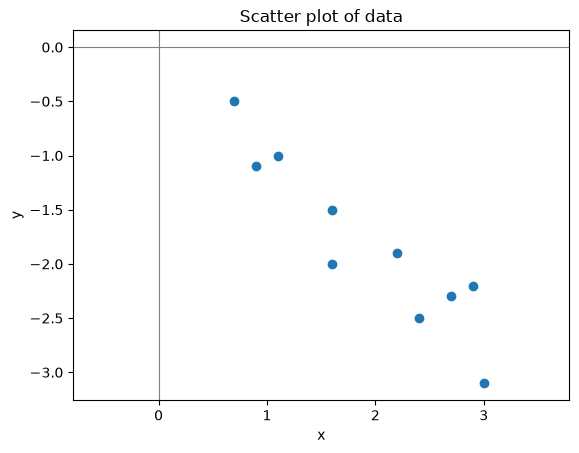

In [12]:
# plot data before centering
plt.scatter(pca_2d[:, 0], pca_2d[:, 1])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter plot of data")
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.axis('equal')
plt.show()

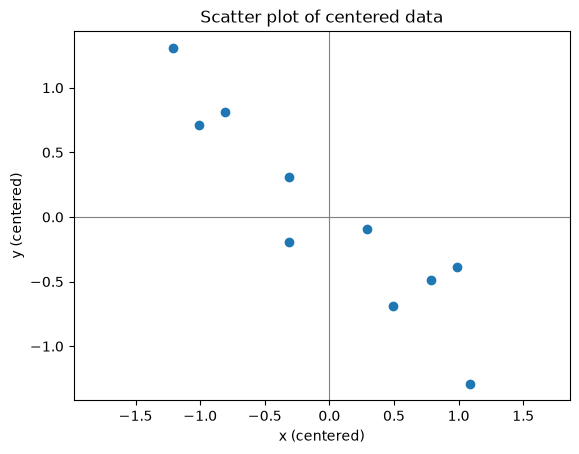

In [13]:
# plot data after centering
plt.scatter(pca_2d_centered[:, 0], pca_2d_centered[:, 1])
plt.xlabel("x (centered)")
plt.ylabel("y (centered)")
plt.title("Scatter plot of centered data")
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.axis('equal')
plt.show()

## H1.1b

In [ ]:
# compute covariance matrix
C = np.cov(pca_2d_centered, rowvar=False) # set cols as features
print(C) # Cov(x,y) and Cov (x,y) are the same as the covariance matrix is symmetric

[[ 0.71655556 -0.61544444]
 [-0.61544444  0.61655556]]


In [ ]:
# compute eigenvalues and eigenvectors
# eigenvectors = principal components
# eigenvalues = amount of variance in direction of principal components
eigenvalues, eigenvectors = np.linalg.eig(C)

print("Eigenvalues:")
print(eigenvalues)

print("")

print("Eigenvectors:")
print(eigenvectors) # eigenvectors are stored as cols

Eigenvalues:
[1.28402771+0.j 0.0490834 +0.j]

Eigenvectors:
[[ 0.73517866+0.j  0.6778734 +0.j]
 [-0.6778734 +0.j  0.73517866+0.j]]


In [15]:
# sort eigenvalues and eigenvectors in descending order (highest to lowest)
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx] # leave rows unattached, just change cols

pcs = eigenvectors
print(pcs)

[[ 0.73517866+0.j  0.6778734 +0.j]
 [-0.6778734 +0.j  0.73517866+0.j]]


In [ ]:
# transform data into new PC basis (project data onto PCs)
pca_2d_pc_coords = pca_2d_centered @ pcs
pca_2d_pc_coords 

array([[ 0.82797019+0.j, -0.17511531+0.j],
       [-1.77758033+0.j,  0.14285723+0.j],
       [ 0.99219749+0.j,  0.38437499+0.j],
       [ 0.27421042+0.j,  0.13041721+0.j],
       [ 1.67580142+0.j, -0.20949846+0.j],
       [ 0.9129491 +0.j,  0.17528244+0.j],
       [-0.09910944+0.j, -0.3498247 +0.j],
       [-1.14457216+0.j,  0.04641726+0.j],
       [-0.43804614+0.j,  0.01776463+0.j],
       [-1.22382056+0.j, -0.16267529+0.j]])

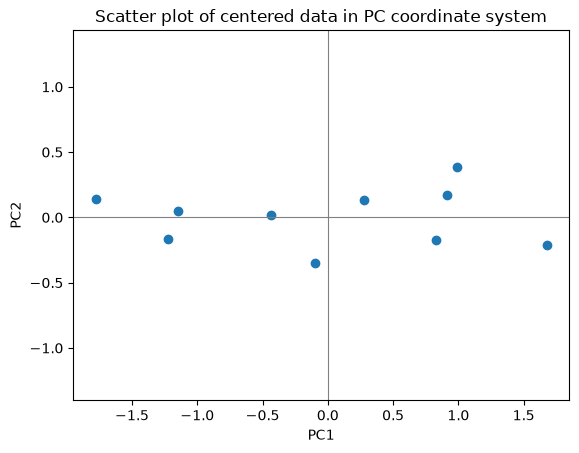

In [18]:
# plot data in new PC basis
plt.scatter(pca_2d_pc_coords[:, 0], pca_2d_pc_coords[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Scatter plot of centered data in PC coordinate system")
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.axis('equal')
plt.show()

## H1.1c

In [ ]:
# select only pc1 coordinates
pc1_coords = pca_2d_pc_coords[:, 0]
print(pc1_coords)

[ 0.82797019+0.j -1.77758033+0.j  0.99219749+0.j  0.27421042+0.j
  1.67580142+0.j  0.9129491 +0.j -0.09910944+0.j -1.14457216+0.j
 -0.43804614+0.j -1.22382056+0.j]


In [ ]:
# select pc1
pc1 = pcs[:, 0]
print(pc1)

[ 0.73517866+0.j -0.6778734 +0.j]


In [ ]:
# reconstruct data points in original feature space via outer product (matrix mul)
pca_2d_centered_reconstructed_pc1 = np.outer(pc1_coords, pc1)
print(pca_2d_centered_reconstructed_pc1)

[[ 0.60870601+0.j -0.56125896+0.j]
 [-1.30683911+0.j  1.20497442-0.j]
 [ 0.72944242+0.j -0.67258429+0.j]
 [ 0.20159364+0.j -0.18587995+0.j]
 [ 1.23201343+0.j -1.1359812 +0.j]
 [ 0.67118069+0.j -0.61886391+0.j]
 [-0.07286314+0.j  0.06718365-0.j]
 [-0.84146502+0.j  0.77587502-0.j]
 [-0.32204217+0.j  0.29693982-0.j]
 [-0.89972675+0.j  0.8295954 -0.j]]


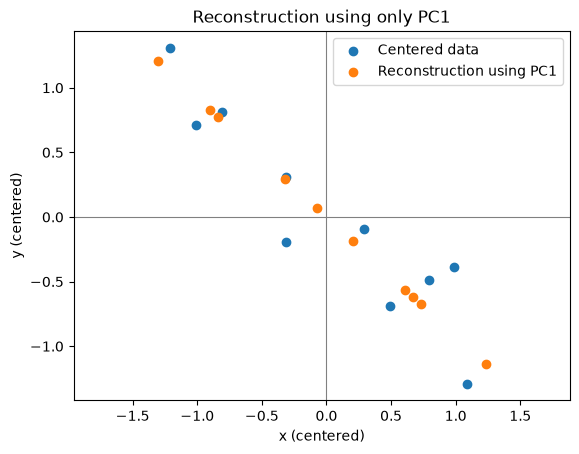

In [ ]:
# plot pc1 reconstruction
plt.scatter(pca_2d_centered[:, 0], pca_2d_centered[:, 1], label="Centered data")
plt.scatter(pca_2d_centered_reconstructed_pc1[:, 0], pca_2d_centered_reconstructed_pc1[:, 1], label="Reconstruction using PC1")
plt.xlabel("x (centered)")
plt.ylabel("y (centered)")
plt.title("Reconstruction using only PC1")
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.axis("equal")
plt.legend()
plt.show()

In [ ]:
# select only pc2 coordinates
pc2_coords = pca_2d_pc_coords[:, 1]
print(pc2_coords)

[-0.17511531+0.j  0.14285723+0.j  0.38437499+0.j  0.13041721+0.j
 -0.20949846+0.j  0.17528244+0.j -0.3498247 +0.j  0.04641726+0.j
  0.01776463+0.j -0.16267529+0.j]


In [ ]:
# select pc2
pc2 = pcs[:, 1]
print(pc2)

[0.6778734 +0.j 0.73517866+0.j]


In [ ]:
# reconstruct data points in original feature space via outer product (matrix mul)
pca_2d_centered_reconstructed_pc2 = np.outer(pc2_coords, pc2)
print(pca_2d_centered_reconstructed_pc2)

[[-0.11870601+0.j -0.12874104+0.j]
 [ 0.09683911+0.j  0.10502558+0.j]
 [ 0.26055758+0.j  0.28258429+0.j]
 [ 0.08840636+0.j  0.09587995+0.j]
 [-0.14201343+0.j -0.1540188 +0.j]
 [ 0.11881931+0.j  0.12886391+0.j]
 [-0.23713686+0.j -0.25718365+0.j]
 [ 0.03146502+0.j  0.03412498+0.j]
 [ 0.01204217+0.j  0.01306018+0.j]
 [-0.11027325+0.j -0.1195954 +0.j]]


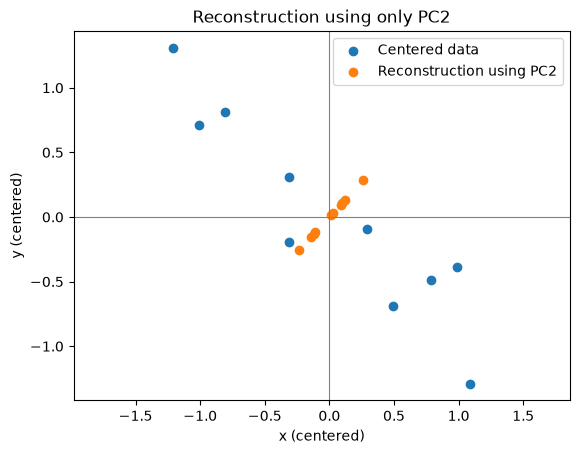

In [27]:
# plot pc2 reconstruction
plt.scatter(pca_2d_centered[:, 0], pca_2d_centered[:, 1], label="Centered data")
plt.scatter(pca_2d_centered_reconstructed_pc2[:, 0], pca_2d_centered_reconstructed_pc2[:, 1], label="Reconstruction using PC2")
plt.xlabel("x (centered)")
plt.ylabel("y (centered)")
plt.title("Reconstruction using only PC2")
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.axis("equal")
plt.legend()
plt.show()

## Exercise H1.2: PCA: 3-dimensional Toy Data

## H.1.2a